# Imports

In [1]:
# --- path setup ---
from sys import path  # add directory where starships is located
path.append('/home/mathisb/Github/starships')

import os  # add directory containing the input data (opacity, abundance and stellar specs files)
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-rdoyon/shared/Models/petitRADTRANS/input_data/'

from pathlib import Path

# --- standard libraries ---
import logging
import warnings
from importlib import reload
from itertools import product

# --- scientific libraries ---
import numpy as np
from scipy.interpolate import interp1d

# --- astropy ---
import astropy.units as u
import astropy.constants as const
from astropy import stats

# --- matplotlib ---
import matplotlib.pyplot as plt
from matplotlib import cm, gridspec, set_loglevel
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase

# --- starships modules ---
from starships import homemade as hm
from starships import correlation as corr
import starships.correlation_class as cc
import starships.plotting_fcts as pf
import starships.planet_obs as pl_obs
from starships.correlation_class import Correlations
from starships.planet_obs import Observations, Planet

# --- configuration ---
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
logging.getLogger("fontTools.subset").setLevel(logging.WARNING)

couleurs = hm.get_colors('magma', 50)[5:-2]

# Correlation setup

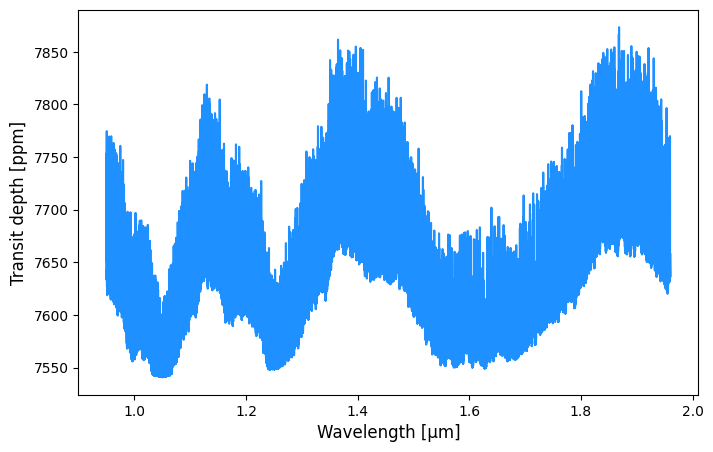

In [36]:
# BASIC INFORMATION
pl_name = "TRAPPIST-1 g"
instrument = "NIRPS"  # SPIRou_with_persi, NIRPS

# # TRAPPIST-1 b
# ap     = 0.01154*u.au        # semi-major axis of planet
# R_pl   = 1.116*u.R_earth     # radius of planet
# R_star = 0.1192*u.R_sun      # radius of star
# M_star = 0.0898*const.M_sun  # mass of star
# e      = 0                   # eccentricity
# w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

# # TRAPPIST-1 d
# ap     = 0.02227*u.au        # semi-major axis of planet
# R_pl   = 0.788*u.R_earth     # radius of planet
# R_star = 0.1192*u.R_sun      # radius of star
# M_star = 0.0898*const.M_sun  # mass of star
# e      = 0                   # eccentricity
# w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

# # TRAPPIST-1 e
# ap     = 0.02925*u.au        # semi-major axis of planet
# R_pl   = 0.920*u.R_earth     # radius of planet
# R_star = 0.1192*u.R_sun      # radius of star
# M_star = 0.0898*const.M_sun  # mass of star
# e      = 0                   # eccentricity
# w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

# # TRAPPIST-1 f
# ap     = 0.03849*u.au        # semi-major axis of planet
# R_pl   = 1.045*u.R_earth     # radius of planet
# R_star = 0.1192*u.R_sun      # radius of star
# M_star = 0.0898*const.M_sun  # mass of star
# e      = 0                   # eccentricity
# w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

# TRAPPIST-1 g
ap     = 0.04683*u.au        # semi-major axis of planet
R_pl   = 1.129*u.R_earth     # radius of planet
R_star = 0.1192*u.R_sun      # radius of star
M_star = 0.0898*const.M_sun  # mass of star
e      = 0                   # eccentricity
w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)


# NIGHTS TO CROSS-CORRELATE WITH
nightlist = [
    # SPIRou b
            # "2019-06-14",
            # "2019-09-25",
            # "2020-05-31",
            # "2020-08-04",
            # "2020-09-08",
            # "2020-09-20",
            # "2020-09-26",
            # "2020-09-29",
            # "2021-10-21",
            # "2021-10-24",
            # "2021-10-27"
    # NIRPS b
            # '2023-09-07',
            # '2024-07-05',
            # '2024-07-11b',
    # NIRPS d
            # '2023-06-08',
            # '2023-08-12',
            # '2023-08-24',
            # '2023-10-20',
    # NIRPS e
            # '2023-07-17',
            # '2023-11-04',
            # '2024-07-11e',
    # NIRPS f
            # '2023-08-28',
            # '2024-11-02',
            # '2025-08-06',
    # NIRPS g
            # '2023-10-05',
            '2023-11-11',
            '2025-07-08',
               ]


# MODEL DETAILS
model_directory = "/home/mathisb/Github/HRS_models/"  # where to find the models
# model_filename = "prt_model_TRAPPIST-1b_H2O_v03.npz"  # name of npz model file: CO2_v05, CH4_v01, H2O_v03
model_filename = "prt_model_TRAPPIST-1g_H2O_NIRPS_full.npz"  # name of npz model file: CO2, CH4, H2O


# REDUCTION DETAILS
reduc_version = 'v001'
nPC_list = [0]

# Where are the reductions
reduc_in_scratch = True  # in the scratch directory (True) or in the home directory (False)


# CORRELATION DETAILS
kind_trans = 'transmission'  # emission or transmission

# Define cross-correlation axes
step_RV_inj = 2.0  # SPIROU: 2.14 (twice the resolution of SPIRou in km/s); NIRPS: 2.0
corr_xlim = 150  # correlation will be done with Vrad values in [-corr_xlim, corr_xlim]

# Where to output the correlations
output_in_scratch = True  # in the scratch directory (True) or in the home directory (False)


#------------------------------------------------------------------------------------------#


# Load the model
model_file = np.load(model_directory + model_filename)
wave_mod, model_spec = model_file['wave_mod'], model_file['model_spec']

if 'NIRPS' in instrument:
    # cut off the model at the NIRPS wavelengths
    model_spec = model_spec[wave_mod <= 1.96]
    wave_mod = wave_mod[wave_mod <= 1.96]

# Plot it
plt.figure(figsize=(8,5))
plt.plot(wave_mod, model_spec * 1e6, color="dodgerblue")
# plt.axhline(5 + (R_pl.to(u.R_sun).value / R_star.value) **2 * 1e6, color='r')  # plot the cutoff under which orders are rejected

plt.xlabel('Wavelength [μm]', fontsize=12)
plt.ylabel('Transit depth [ppm]', fontsize=12)  # transit depth: $(\frac{R_{\rm p}}{R_{\rm \star}})^2$
plt.show()


In [37]:
# OTHER INFORMATION

# Mid-transit time (BJD) of each TRAPPIST-1 visit (calculated from Agol et al. 2024)
mid_tr_dict = {
        # SPIRou b
               "2019-06-14": 2458649.07123371738 * u.d,
               "2019-09-25": 2458751.8112203472  * u.d,
               "2020-05-31": 2459001.10676193183 * u.d,
               "2020-08-04": 2459066.07481311538 * u.d,
               "2020-09-08": 2459100.82490738839 * u.d,
               "2020-09-20": 2459112.91190875796 * u.d,
               "2020-09-26": 2459118.95517847751 * u.d,
               "2020-09-29": 2459121.9775049779  * u.d,
               "2021-10-21": 2459508.76251261068 * u.d,
               "2021-10-24": 2459511.78471495466 * u.d,
               "2021-10-27": 2459514.8059938763  * u.d,
        # NIRPS b
               "2023-09-07": 2460194.7007329288  * u.d,
               "2024-07-05": 2460496.8725766301  * u.d,
               "2024-07-11b": 2460502.9159761349 * u.d,
        # NIRPS d
               "2023-06-08": 2460103.8951073092 * u.d,
               "2023-08-12": 2460168.6902942523 * u.d,
               "2023-08-24": 2460180.8397053848 * u.d,
               "2023-10-20": 2460237.5365671548 * u.d,
        # NIRPS e
               "2023-07-17": 2460142.858565431  * u.d,
               "2023-11-04": 2460252.6376593957 * u.d,
               "2024-07-11e": 2460502.7365562134 * u.d,
        # NIRPS f
               "2023-08-28": 2460184.827486578  * u.d,
               "2024-11-02": 2460617.5481359637 * u.d,
               "2025-08-06": 2460893.795434583  * u.d,
        # NIRPS g
               "2023-10-05": 2460222.5638302773 * u.d,
               "2023-11-11": 2460259.6204310769 * u.d,
               "2025-07-08": 2460864.8974261757 * u.d,
                }

# Planet parameters dict
pl_kwargs = {'M_star': M_star, 
             'R_star': R_star,
             'ap': ap,
             'R_pl': R_pl,
             'excent': e,
             'w': w}


# Reduction filenames
filename_list = [
    f"sequence_{n}-pc_mask_wings97_data_trs_{visit}.npz"
    for visit in nightlist
    for n in nPC_list
]

# Some names for files
pl_name_fname = ''.join(pl_name.split())
model_name = '_'.join(model_filename[:-4].split('_')[-3:])


# Run the correlations

In [38]:
pl_obs.log.setLevel("WARNING")  # do not print all the log information


# Correlation variables
corrRV0 = np.arange(-corr_xlim, corr_xlim, step_RV_inj)  # x axis (Vrad)
all_obs = dict()
all_ccf_map = dict()
all_logl_map = dict()


for filename in filename_list:

    visit_name = filename[:-4].split('_')[-1]
    
    # Create the planet object
    mid_tr = mid_tr_dict[visit_name]
    pl_kwargs['mid_tr'] = mid_tr
    pl_kwargs['t_peri'] = mid_tr

    planet_obj = Planet(pl_name, **pl_kwargs)

    
    # Directory where the reductions are
    if reduc_in_scratch:
        base_dir = Path(os.environ['SCRATCH'])
    else:
        base_dir = Path.home() / "Github"
    
    reduc_dir = base_dir / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/{reduc_version}')


    # Directory where the correlations are
    if output_in_scratch:
        output_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')
    else:
        output_dir = Path(f'/home/mathisb/Github/HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')

    # Create figures directory if it does not exist
    fig_dir = output_dir / "Figures"
    fig_dir.mkdir(parents=True, exist_ok=True)


    # Create the observation object
    obs = pl_obs.load_single_sequences(filename, pl_name, path=reduc_dir, load_all=False, filename_end='', plot=False, planet=planet_obj)

    # Generate Kp 
    Kp_array = np.array([obs.Kp.value])

    n_pc = int(obs.params[5])
    mask_wings = int(obs.params[1] * 100)  # in percent
    
    out_filename = f'{Path(filename).stem}_ccf_logl_seq_{model_name}'


    print(f"\033[1mCorrelation for {visit_name} with {n_pc} PC\033[0m")
    print("Reduction directory is:", reduc_dir)
    print("Correlations directory is:", output_dir)

    
    try:
        # Check if already generated
        saved_values = np.load(output_dir / Path(out_filename).with_suffix('.npz'))
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']
        print(f"Correlation already generated. Loading saved values...")
        print("-------------------------\n")
        
    except FileNotFoundError:
        # Generate 1d correlations  --  ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model) 
        ccf_map, logl_map = corr.calc_logl_injred(obs, 'seq', planet_obj, Kp_array, corrRV0, [n_pc], wave_mod, model_spec, kind_trans)
        corr.save_logl_seq(output_dir / Path(out_filename), ccf_map, logl_map, wave_mod, model_spec, n_pc, Kp_array, corrRV0, kind_trans)
    
    all_obs[(visit_name, n_pc)] = obs
    all_ccf_map[(visit_name, n_pc)] = ccf_map
    all_logl_map[(visit_name, n_pc)] = logl_map


pl_obs.log.setLevel("INFO")  # go back to normal log printing

Correlation for 2023-11-11 with 0 PC
Reduction directory is: /scratch/mathisb/HRS_reductions/NIRPS/TRAPPIST-1g/2023-11-11/v001
Correlations directory is: /scratch/mathisb/HRS_correlations/NIRPS/TRAPPIST-1g/2023-11-11
Correlation already generated. Loading saved values...
-------------------------

Correlation for 2025-07-08 with 0 PC
Reduction directory is: /scratch/mathisb/HRS_reductions/NIRPS/TRAPPIST-1g/2025-07-08/v001
Correlations directory is: /scratch/mathisb/HRS_correlations/NIRPS/TRAPPIST-1g/2025-07-08
Correlation already generated. Loading saved values...
-------------------------



# Plot the correlations

## Cross-correlation time series in planet rest frame

2023-11-11
Orders used in the analysis: [7, 8, 9, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]
Max value at 0 nPC = -0.4038647639561225 at -7.9999948521443836 km/s
Max value at 0 nPC = -0.40433812509459893 at -7.9999948521443836 km/s
Max value at 0 nPC = -0.40433812509459893 at -7.9999948521443836 km/s


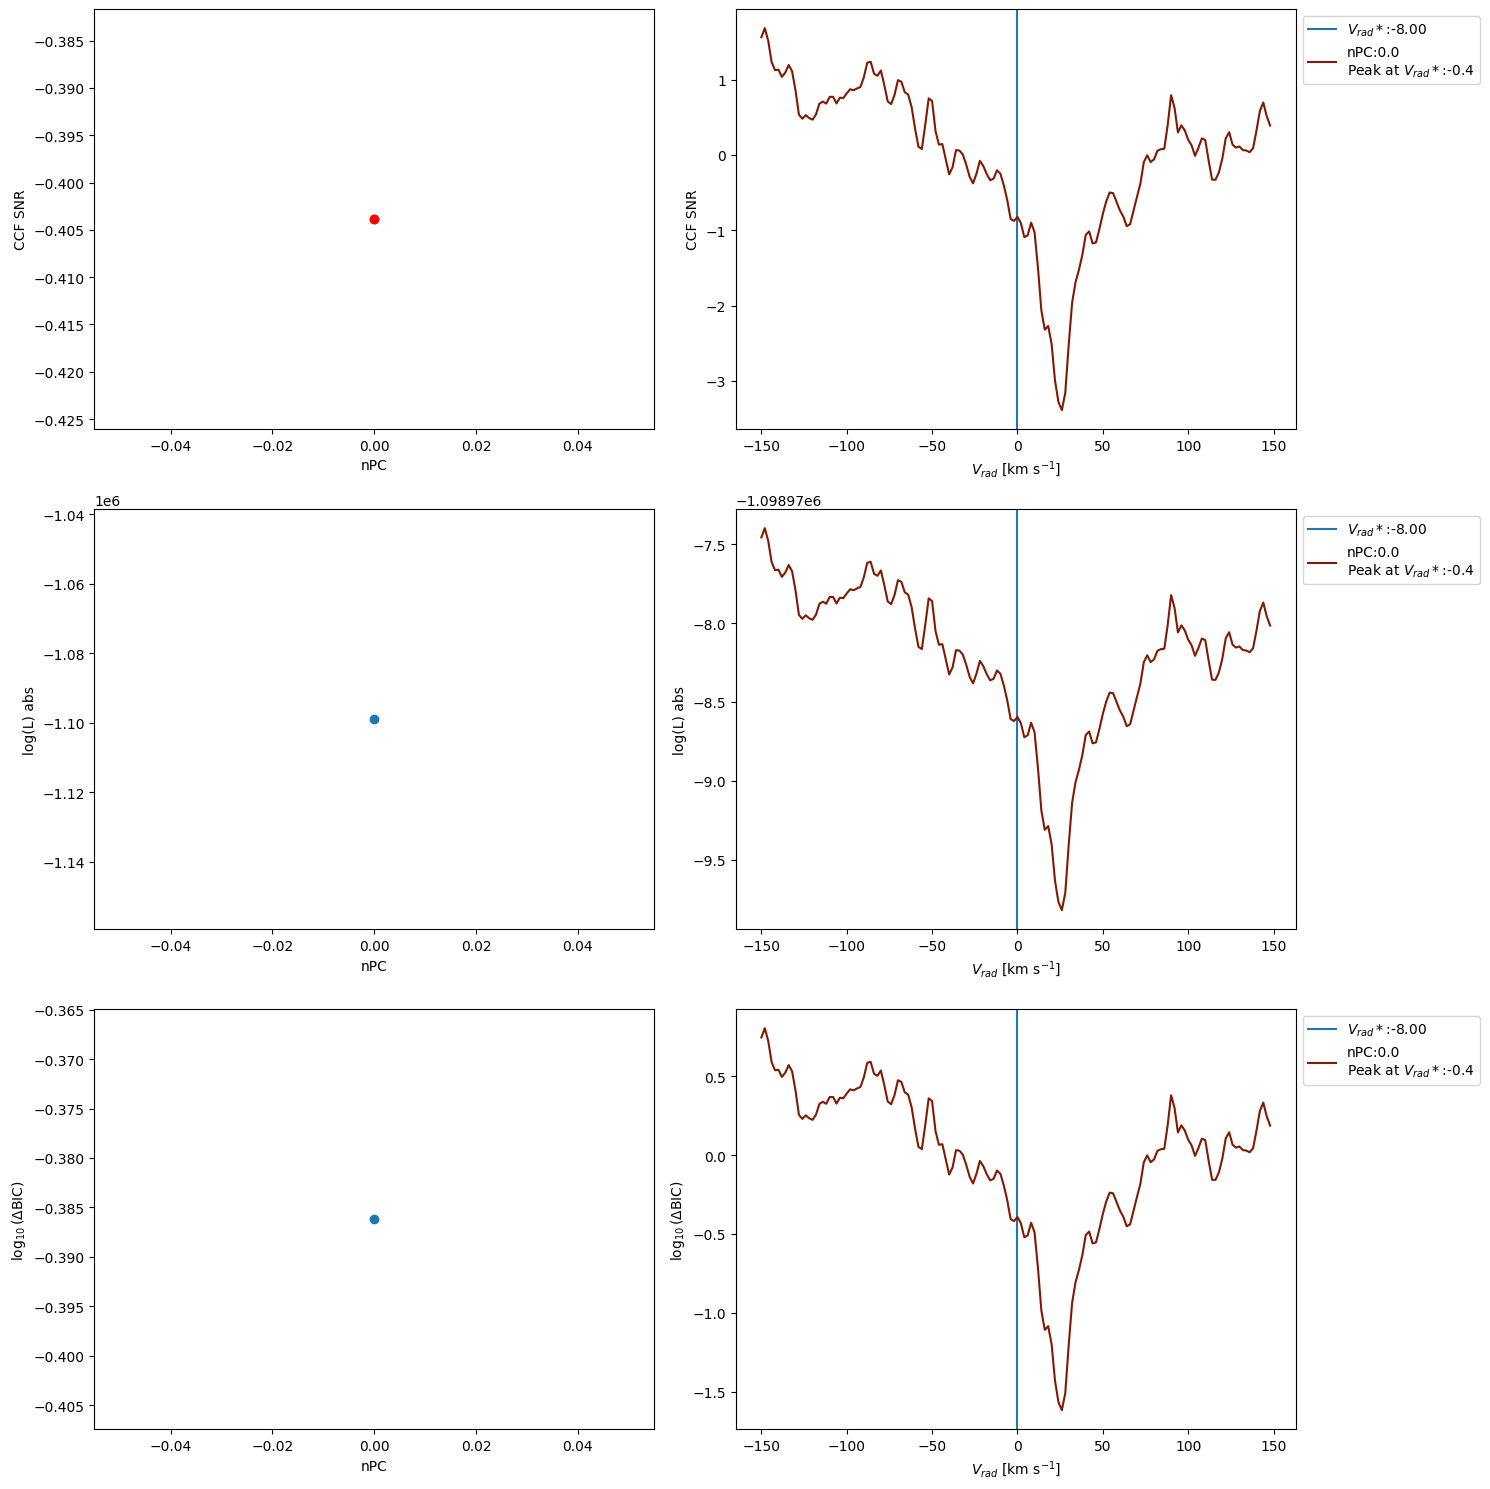

CCF SNR peak at Vrad*: [-0.40386476]
log(L) abs peak at Vrad*: [-1098978.39573046]
log_10(ΔBIC) peak at Vrad*: [-0.38619054]
Saved file to :  /scratch/mathisb/HRS_correlations/NIRPS/TRAPPIST-1g/2023-11-11/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2023-11-11_ccf_logl_seq_H2O_NIRPS_full_pc0.pdf
In-transit t-val = -0.47 / p-val 6.49e-01 / sig = -0.38
Out-of-transit t-val = -0.62 / p-val 5.78e-01 / sig = -0.20


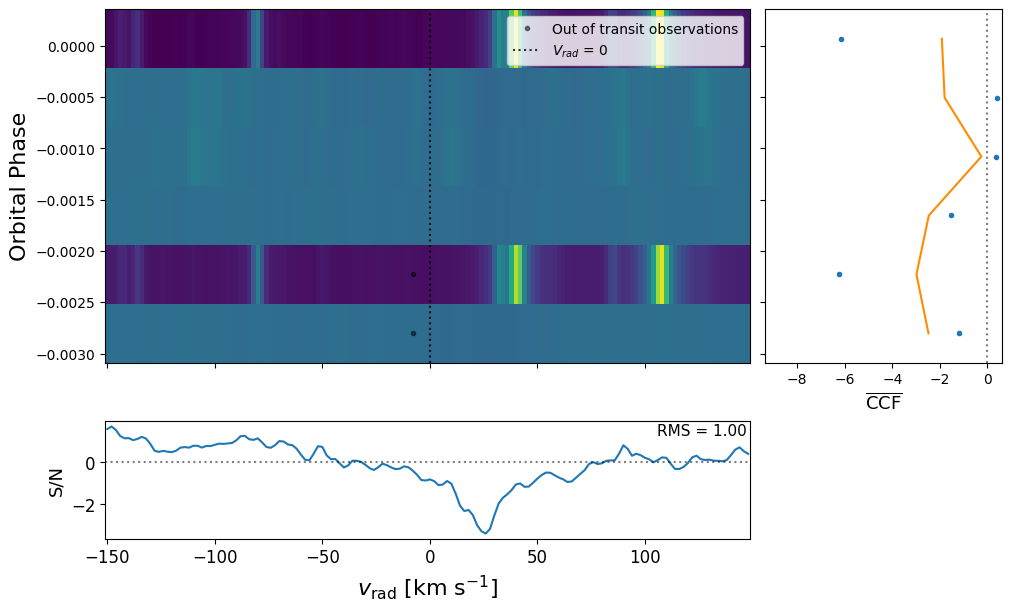



2025-07-08
Orders used in the analysis: [7, 8, 9, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]
Max value at 0 nPC = 0.1735094310695307 at -4.096247941032719 km/s
Max value at 0 nPC = 0.1738153421428556 at -4.095994317129637 km/s
Max value at 0 nPC = 0.1738153421428556 at -4.095994317129637 km/s


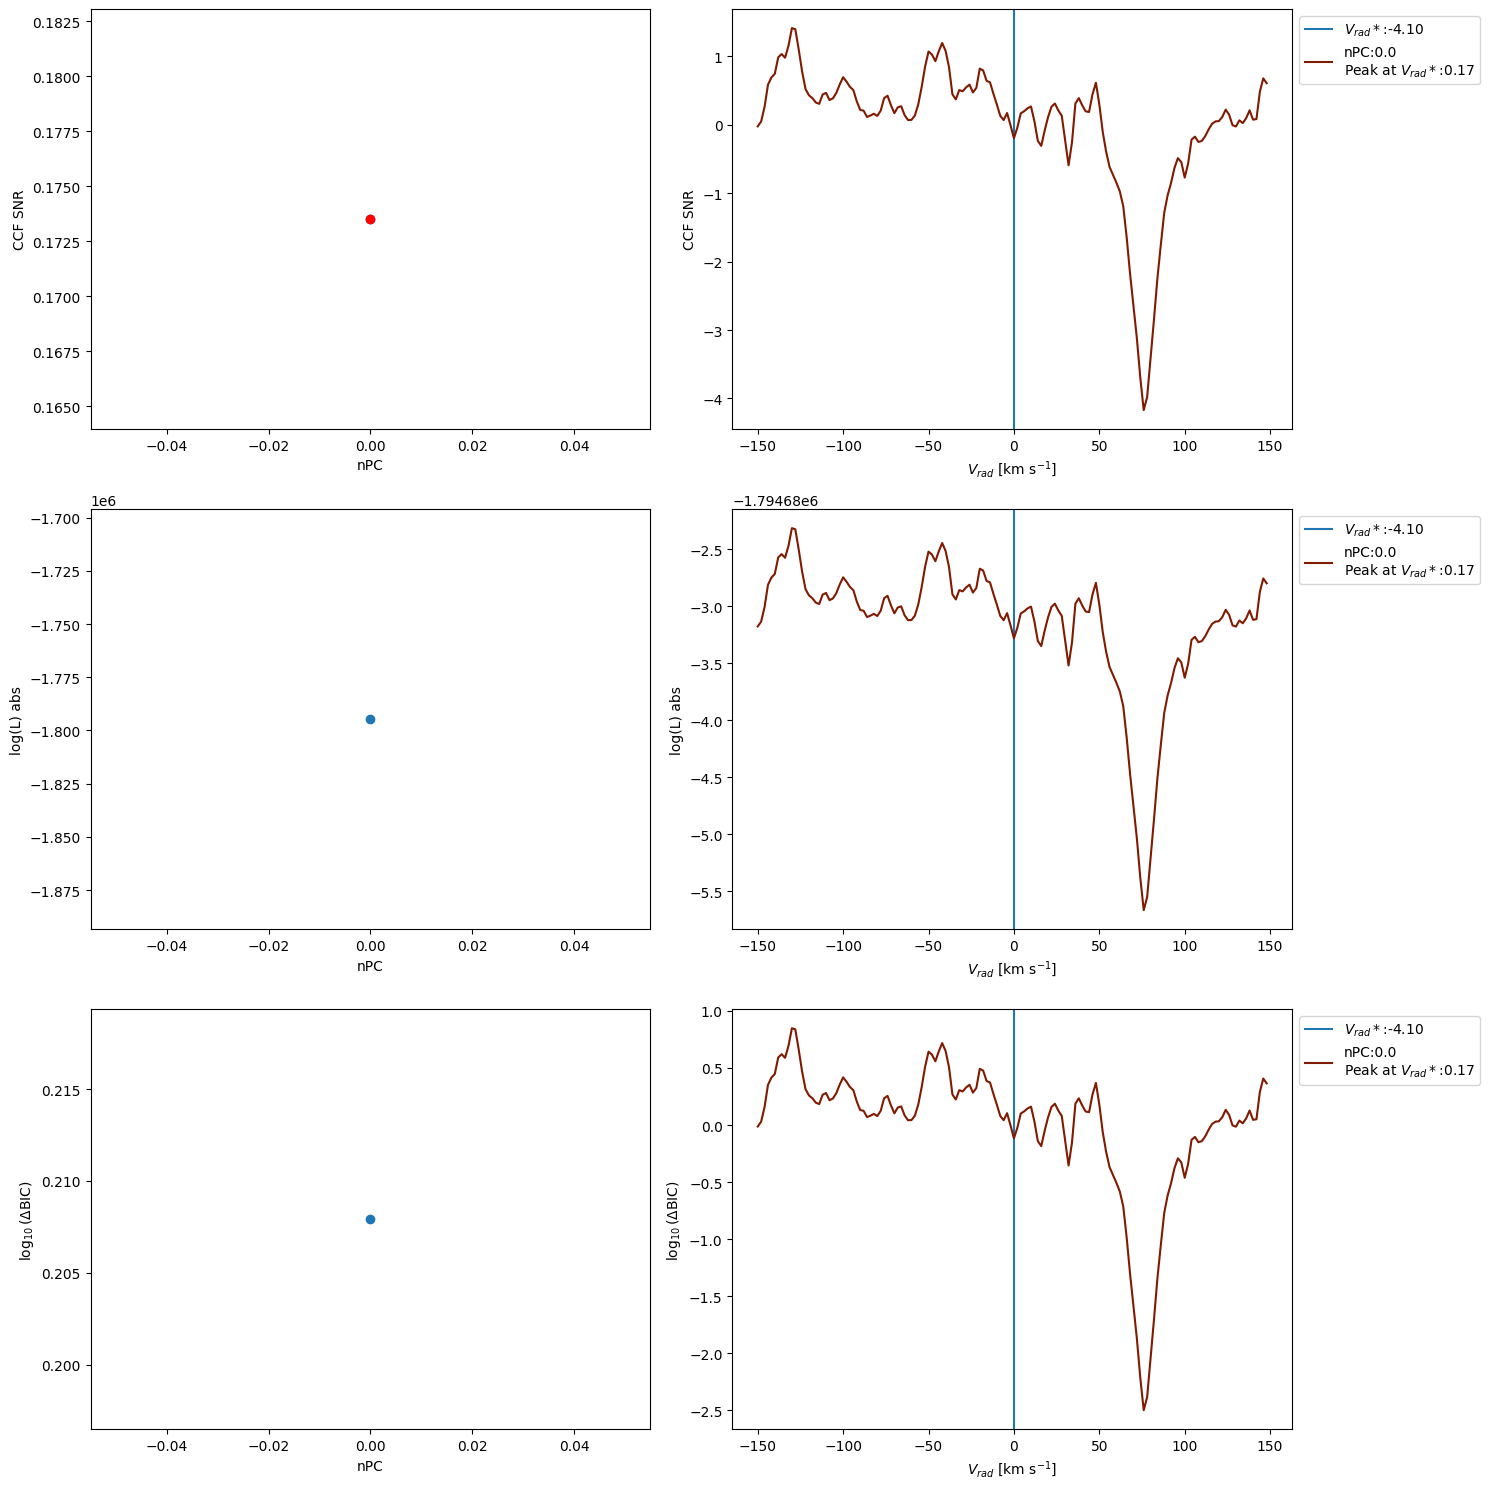

CCF SNR peak at Vrad*: [0.17350943]
log(L) abs peak at Vrad*: [-1794683.06124776]
log_10(ΔBIC) peak at Vrad*: [0.20791828]
Saved file to :  /scratch/mathisb/HRS_correlations/NIRPS/TRAPPIST-1g/2025-07-08/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2025-07-08_ccf_logl_seq_H2O_NIRPS_full_pc0.pdf
In-transit t-val = 2.08 / p-val 5.07e-02 / sig = 1.64
Out-of-transit t-val = -3.89 / p-val 4.34e-04 / sig = 3.33


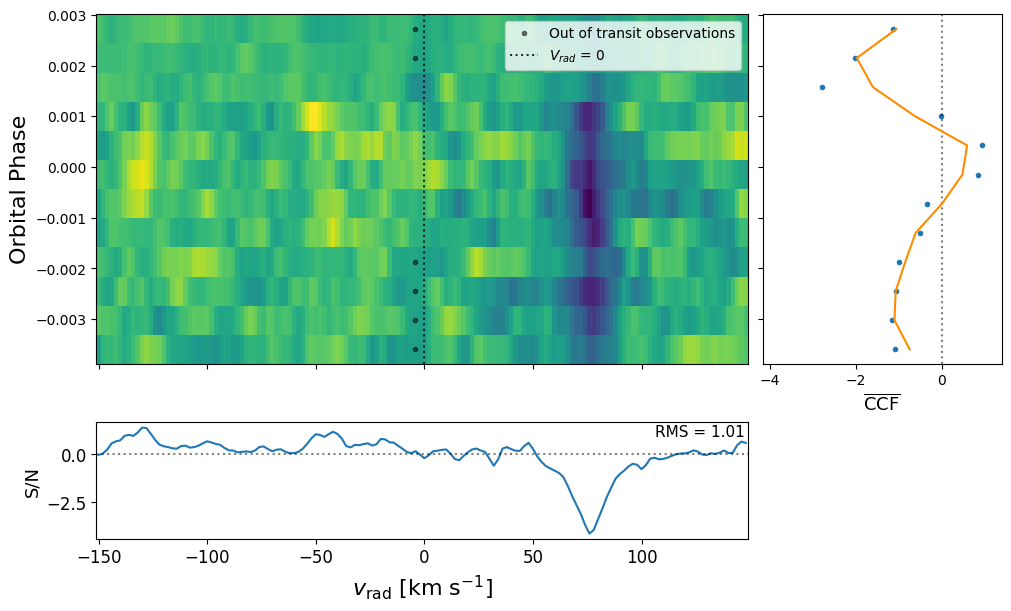

In [39]:
# CHOOSE NIGHTS TO PLOT
visits_plot = [
    # SPIRou b
            # "2019-06-14",
            # "2019-09-25",
            # "2020-05-31",
            # "2020-08-04",
            # "2020-09-08",
            # "2020-09-20",
            # "2020-09-26",
            # "2020-09-29",
            # "2021-10-21",
            # "2021-10-24",
            # "2021-10-27"
    # NIRPS b
            # '2023-09-07',
            # '2024-07-05',
            # '2024-07-11b',
    # NIRPS d
            # '2023-06-08',
            # '2023-08-12',
            # '2023-08-24',
            # '2023-10-20',
    # NIRPS e
            # '2023-07-17',
            # '2023-11-04',
            # '2024-07-11e',
    # NIRPS f
            # '2023-08-28',
            # '2024-11-02',
            # '2025-08-06',
    # NIRPS g
            # '2023-10-05',
            '2023-11-11',
            '2025-07-08',
               ]


# OPTIONAL: plot a specific number of PCs
n_pc_plot = 0  # int or None -- if None, shows best nPC values


# CRITERIA TO EXCLUDE AN ORDER
max_masked_ratio = 0.9  # excludes the orders where the ratio of masked data points is too high
min_SNR = 5            # excludes the orders where the instrument SNR is too low
min_model_ppm = 5       # excludes the orders where the model atmosphere is close to 0 ppm in transit depth

# ADITTIONAL ORDERS TO EXCLUDE
# orders_to_delete = [[0,1,2,3,4], [10,11,12,13,14], [23,24,25], [37,38,39], [46,47,48]]  # SPIRou
# orders_to_delete = [[43,44,45,46,47], [71,72,73,74]]  # NIRPS
orders_to_delete = []  # leave empty if not needed

#-------------------------------------------------------------------------------------#


# Masks for the array of orders
masked_ratio_mask = np.array([obs.final.mask.sum(axis=0).sum(axis=-1) / obs.final.shape[0] / obs.final.shape[-1]])[0] < max_masked_ratio  # mask for ratio of masked data points
SNR_mask = np.nanmean(obs.SNR, axis=0).T > min_SNR  # mask for SNR at the instrument

# Model depth mask
model_depth_wv_mask = (model_spec - (R_pl.to(u.R_sun).value / R_star.value) **2) * 1e6 > min_model_ppm  # mask for transit depth of the model atmosphere (minus the planet radius) 
interp_mask = interp1d(wave_mod, model_depth_wv_mask.astype(float), bounds_error=False, fill_value=0.0)  # interpolate mask to the data wv array (convert bool to float for interpolation)

model_depth_mask = []

for wv in obs.wave[0]:  # loop over all orders
    mask_interp = interp_mask(wv) > 0.5  # convert back to boolean
    frac_higher_than_limit = np.mean(mask_interp)  # fraction of model points higher than minimum ppm
    model_depth_mask.append(frac_higher_than_limit > 0.80)  # orders are accepted if more than 80% of the order has a model > ppm limit

model_depth_mask = np.array(model_depth_mask)

orders_masked = np.arange(obs.nord)[masked_ratio_mask & SNR_mask & model_depth_mask]  # filter the orders

# Remove orders to delete from array of orders
order_indices = np.setdiff1d(orders_masked, orders_to_delete)


for visit_name in visits_plot:

    # Directory where the correlations are
    if output_in_scratch:
        output_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')
    else:
        output_dir = Path(f'/home/mathisb/Github/HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')

    # Create figures directory if it does not exist
    fig_dir = output_dir / "Figures"
    fig_dir.mkdir(parents=True, exist_ok=True)

    
    print(f"\033[1m{visit_name}\033[0m")
    print('Orders used in the analysis:', list(order_indices))


    if n_pc_plot is None:  # if nPC has not been specified

        # Plot all ccf and logl as a function of nPC
        ccf_maps_in = np.concatenate([all_ccf_map[(visit_name, n)] for n in nPC_list], axis=-2)
        logl_maps_in = np.concatenate([all_logl_map[(visit_name, n)] for n in nPC_list], axis=-2)
        obs = all_obs[(visit_name, nPC_list[0])]


        id_pc0 = 0  # don't change
        n_pc_str = '-'.join(str(i) for i in nPC_list)
        fig_name = f'sequence_{n_pc_str}-pc_mask_wings97_data_trs_{visit_name}_ccf_logl_seq_{model_name}'


        ccf_obj, logl_obj = cc.plot_ccflogl(obs, ccf_maps_in, logl_maps_in, corrRV0, Kp_array, nPC_list, orders=order_indices,
                                            id_pc0=id_pc0, cmap="viridis", path_fig=str(fig_dir) + "/", fig_name=fig_name)

    else:
        
        fig_name = f'sequence_{n_pc_plot}-pc_mask_wings97_data_trs_{visit_name}_ccf_logl_seq_{model_name}'

        
        args = [all_something[(visit_name, n_pc_plot)] for all_something in [all_obs, all_ccf_map, all_logl_map]]
        ccf_obj, logl_obj = cc.plot_ccflogl(*args, corrRV0, Kp_array, [n_pc_plot], orders=order_indices,
                                            cmap="viridis", path_fig=str(fig_dir) + "/", fig_name=fig_name)

    
    plt.show()
    print("\n")
    

## Kp/Vrad plots

**Methods:**
- T-test map + distributions of cross-correlation values
- Box method
- Sigma-clipping

**Optional: plot all orders**

2023-11-11 | nPC=0
Tellurics should be at RV ≈ 25.3


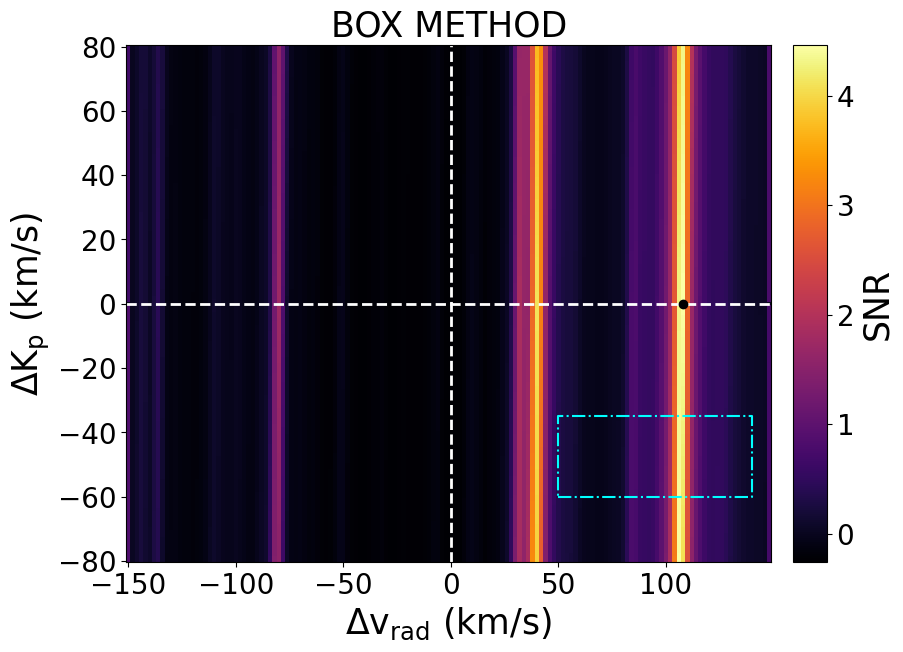

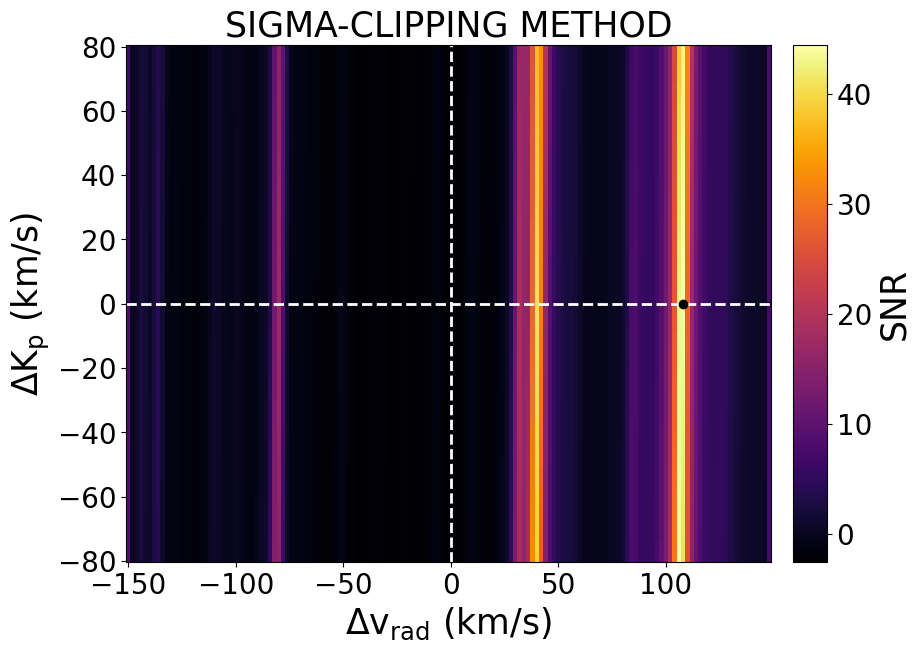

2025-07-08 | nPC=0
Tellurics should be at RV ≈ 77.3


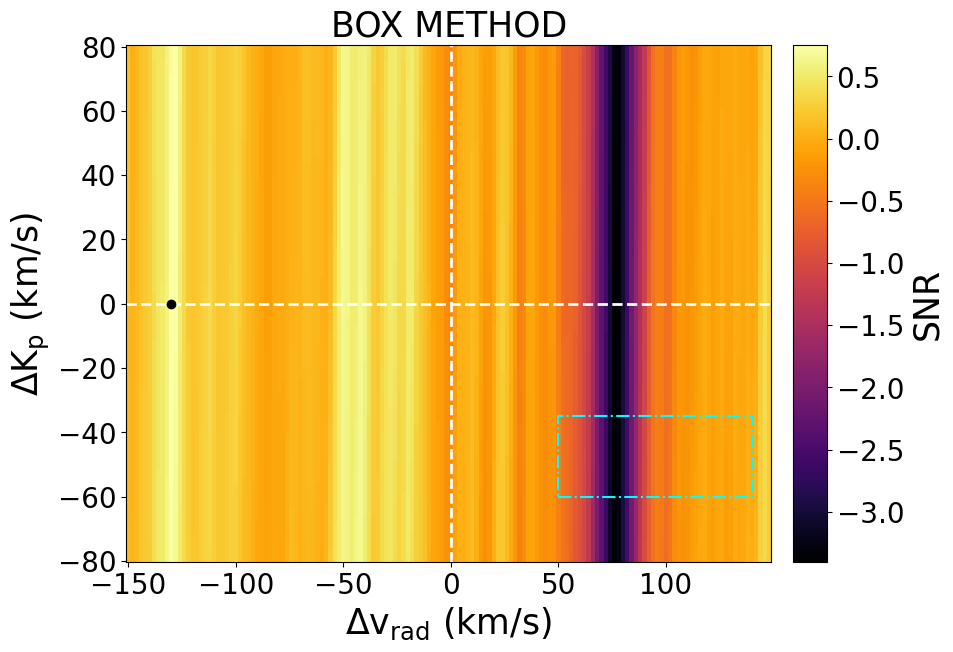

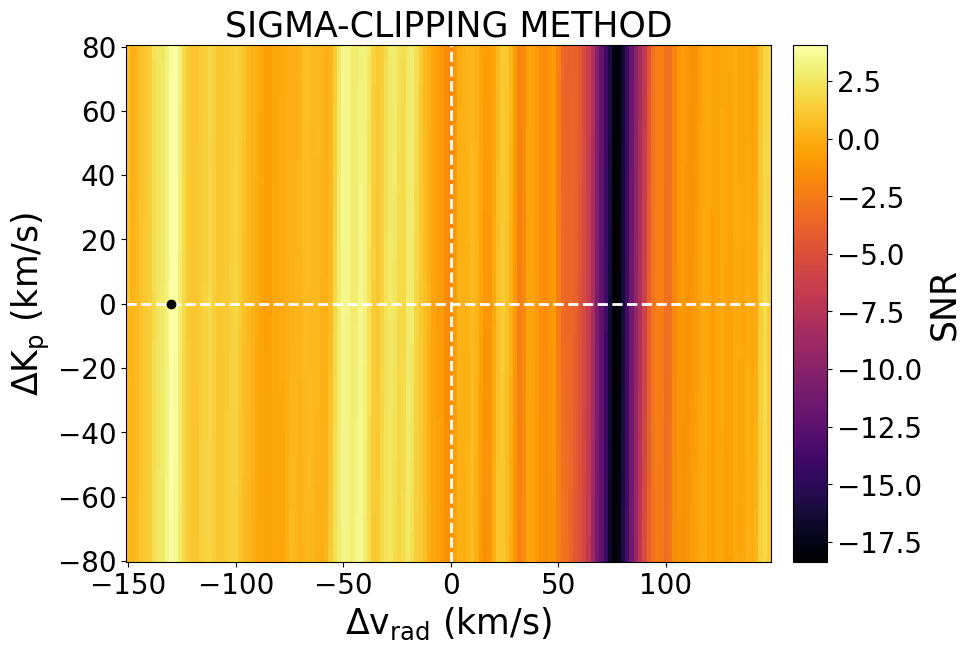

In [40]:
# CHOOSE METHOD
methods = [
        # 'ttest',
        'box',
        'clip'
          ]

# Choose Vrad (x-axis) Kp (y-axis) values for the plot
rv_grid = corrRV0
kp_grid = np.linspace(-80, 80, 161)

# Set Vrad and Kp limits for the box in the box method
box_Vrad = (50, 140)
box_Kp = (-60, -35)

# Set sigma limit and max number of iterations for the sigma-clipping method
clip_sigma = 2
clip_iter = 9


# PLOT THE CORRELATION MAP FOR EACH ORDER
plot_all_orders = False


# PLOT EACH ORDER OF THE MODEL
plot_model_orders = False
plot_these_orders = np.arange(10,12)  # 'all' or an array of specific orders
save_in_pdf = False  # save this plot in a pdf


#----------------------------------------------------------------#


for visit_name in visits_plot:
    
    # Build the list of (npc, obs) to plot for this night
    if n_pc_plot is not None:  # plot a single reduction
        combos = [(n_pc_plot, all_obs[(visit_name, n_pc_plot)])]
        
    else:  # plot all reductions
        combos = [(npc, obs)
                  for (visit, npc), obs in all_obs.items()
                  if visit == visit_name]

    
    # Loop once over whatever we decided to plot
    for npc, obs in combos:
        print(f"\033[1m{visit_name} | nPC={npc}\033[0m")

        berv_rv = -obs.vrp-obs.mid_vrp-obs.RV_sys-(obs.mid_vr+obs.vr)-(obs.mid_berv+obs.berv)
        print(f"Tellurics should be at RV ≈ {np.mean(berv_rv):.1f}")


        # Get the right ccf object
        ccf_obj = Correlations(all_ccf_map[(visit_name, npc)], kind="logl", rv_grid=corrRV0, n_pcas=npc, kp_array=Kp_array)
        ccf_obj.calc_ccf2d(obs, ccf=None, kind='logl_corr', id_pc=None, remove_mean=False, index=None, orders=order_indices)
        ccf_obj.calc_logl(obs, orders=order_indices, index=None, N=None, nolog=False, icorr=obs.iIn, std_robust=True)
        
        
        if 'ttest' in methods:
            ccf_obj.ttest_map(obs, kind='logl', vrp=np.zeros_like(obs.vrp), orders=order_indices, 
                          kp0=0, RV_limit=corr_xlim, kp_step=5, rv_step=2, RV=None, speed_limit=3,
                              icorr=obs.iIn, equal_var=False)
        
        if 'box' in methods:
            pf.calculate_KpVsys_map(obs, ccf_obj, method='box', rv_grid=rv_grid, kp_grid=kp_grid,
                        box_Vrad=box_Vrad, box_Kp=box_Kp)
        
        if 'clip' in methods:
            pf.calculate_KpVsys_map(obs, ccf_obj, method='clip', rv_grid=rv_grid, kp_grid=kp_grid,
                        clip_sigma=clip_sigma, clip_iter=clip_iter)

        if plot_all_orders:
            pf.plot_all_orders_correl(corrRV0, ccf_obj.data.squeeze(), obs, icorr=None, logl=False, sharey=True,
                              vrp=np.zeros_like(obs.vrp), RV_sys=0.0, vmin=None, vmax=None, vline=None,
                              hline=2, kind='snr', return_snr=False, orders=order_indices)

        if plot_model_orders:
            pdfname = fig_dir / f"model_plot_orderbyorder_{visit_name}_{npc}-pc_maskwings97_{model_name}.pdf"
            pf.plot_model_orders(obs, wave_mod, model_spec, order_indices, plot_these_orders=plot_these_orders,
                                 save_in_pdf=save_in_pdf, pdfname=pdfname)


# Combined

## Combined setup

In [12]:
# REDUCTION DETAILS
nPC = 1  # nPC to use

coeffs = [0.02703969,  1.10037972, -0.96372403,  0.28750393]  # limb darkening coefficients
ld_model = 'nonlinear'  # limb darkening model

# Where are the reductions
reduc_in_scratch = True  # in the scratch directory (True) or in the home directory (False)


# CORRELATION DETAILS
kind_trans = 'transmission'  # emission or transmission

# Define cross-correlation axes
step_RV_inj = 2.0  # SPIROU: 2.14 (twice the resolution of SPIRou in km/s); NIRPS: 2.0
corr_xlim = 150  # correlation will be done with Vrad values in [-corr_xlim, corr_xlim]

# Where to find the correlations
corr_in_scratch = True  # in the scratch directory (True) or in the home directory (False)


# NIGHTS TO COMBINE
file_arr = np.array([
                # SPIRou
                    # ['1', '2019-06-14', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2019-06-14.npz'],
                    # ['2', '2019-09-25', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2019-09-25.npz'],
                    # ['3', '2020-05-31', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-05-31.npz'],
                    # ['4', '2020-08-04', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-08-04.npz'],
                    # ['5', '2020-09-08', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-08.npz'],
                    # ['6', '2020-09-20', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-20.npz'],
                    # ['7', '2020-09-26', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-26.npz'],
                    # ['8', '2020-09-29', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-29.npz'],
                    # ['9', '2021-10-21', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-21.npz'],
                    # ['10', '2021-10-24', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-24.npz'],
                    # ['11', '2021-10-27', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-27.npz'],
                # NIRPS
                    ['1', '2023-09-07', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-09-07.npz'],
                    ['2', '2024-07-05', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2024-07-05.npz'],
                    ['3', '2024-07-11', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2024-07-11.npz'],
                    ])


## Run the combined correlation

In [21]:
pl_obs.log.setLevel("WARNING")  # do not print entire log in this cell


# Correlation setup
corrRV0 = np.arange(-corr_xlim, corr_xlim, step_RV_inj)  # x axis (Vrad)
combined_ccf = []
combined_logl = []
combined_obs = []
visit_dict = dict()
all_visits_str = ""


for reduc_idx, reduc in enumerate(file_arr):
    
    visit_nb = reduc[0]
    visit = reduc[1]
    version = reduc[2]
    fname = reduc[3]

    
    print("Loading", visit, "correlation...")

    
    # Directory where the reductions are
    if reduc_in_scratch:
        base_dir = Path(os.environ['SCRATCH'])
    else:
        base_dir = Path.home() / "Github"
    
    reduc_dir = base_dir / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit}/{version}')


    # Directory where the correlations are
    if corr_in_scratch:
        corr_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit}')
    else:
        corr_dir = Path(f'/home/mathisb/Github/HRS_correlations/{instrument}/{pl_name_fname}/{visit}')

    # Create figures directory if it does not exist
    fig_dir = corr_dir / "Figures"
    fig_dir.mkdir(parents=True, exist_ok=True)


    # Redefine planet (since mid-tr time changes for each visit)
    mid_tr = mid_tr_dict[visit]

    pl_kwargs = {'M_star': M_star, 
                 'R_star': R_star,
                 'ap': ap,
                 'R_pl': R_pl,
                 'mid_tr': mid_tr,
                 't_peri': mid_tr,
                 'excent': e,
                 'w': w}

    planet_obj = Planet(pl_name, **pl_kwargs)
    obs = pl_obs.load_single_sequences(fname, pl_name, path=reduc_dir, load_all=False, filename_end='', plot=False, planet=planet_obj)

    
    out_filename = f'{Path(fname).stem}_ccf_logl_seq_{model_name}'

    
    try:
        # Check if already generated
        saved_values = np.load(corr_dir / Path(out_filename).with_suffix('.npz'))
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']

        
    except FileNotFoundError:
        # Generate 1d correlations  --  ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model)
        ccf_map, logl_map = corr.calc_logl_injred(obs,'seq', planet_obj, Kp_array, corrRV0, [nPC], wave_mod, model_spec, kind_trans)
        corr.save_logl_seq(corr_dir / Path(out_filename), ccf_map, logl_map, wave_mod, model_spec, nPC, Kp_array, corrRV0, kind_trans)
    

    all_visits_str += visit_nb + "-"
    
    visit_dict[str(reduc_idx + 1)] = obs
    combined_obs.append(obs)
    combined_ccf.append(ccf_map)
    combined_logl.append(logl_map)


transit_tags = [np.arange(obs.n_spec) for obs in visit_dict.values()]
all_visits = pl_obs.gen_merge_obs_sequence(obs, visit_dict, np.arange(1, len(file_arr) + 1), None, coeffs, ld_model, kind_trans, light=True)
all_visits.dt = np.concatenate([vst.dt for vst in visit_dict.values()])  # exposure times
all_vists_str = all_visits_str[:-1]
visit_dict[all_visits_str.replace("-", "")] = all_visits


pl_obs.log.setLevel("INFO")  # go back to normal log printing

Loading 2023-09-07 correlation...
Loading 2024-07-05 correlation...
Loading 2024-07-11 correlation...


## Plot the combined correlation

Max value at 1 nPC = 0.49185593981111175 at -1.9973159053962999 km/s
Max value at 1 nPC = 0.4980063051503366 at -1.9951791011357896 km/s
Max value at 1 nPC = 0.4980063051503366 at -1.9951791011357896 km/s


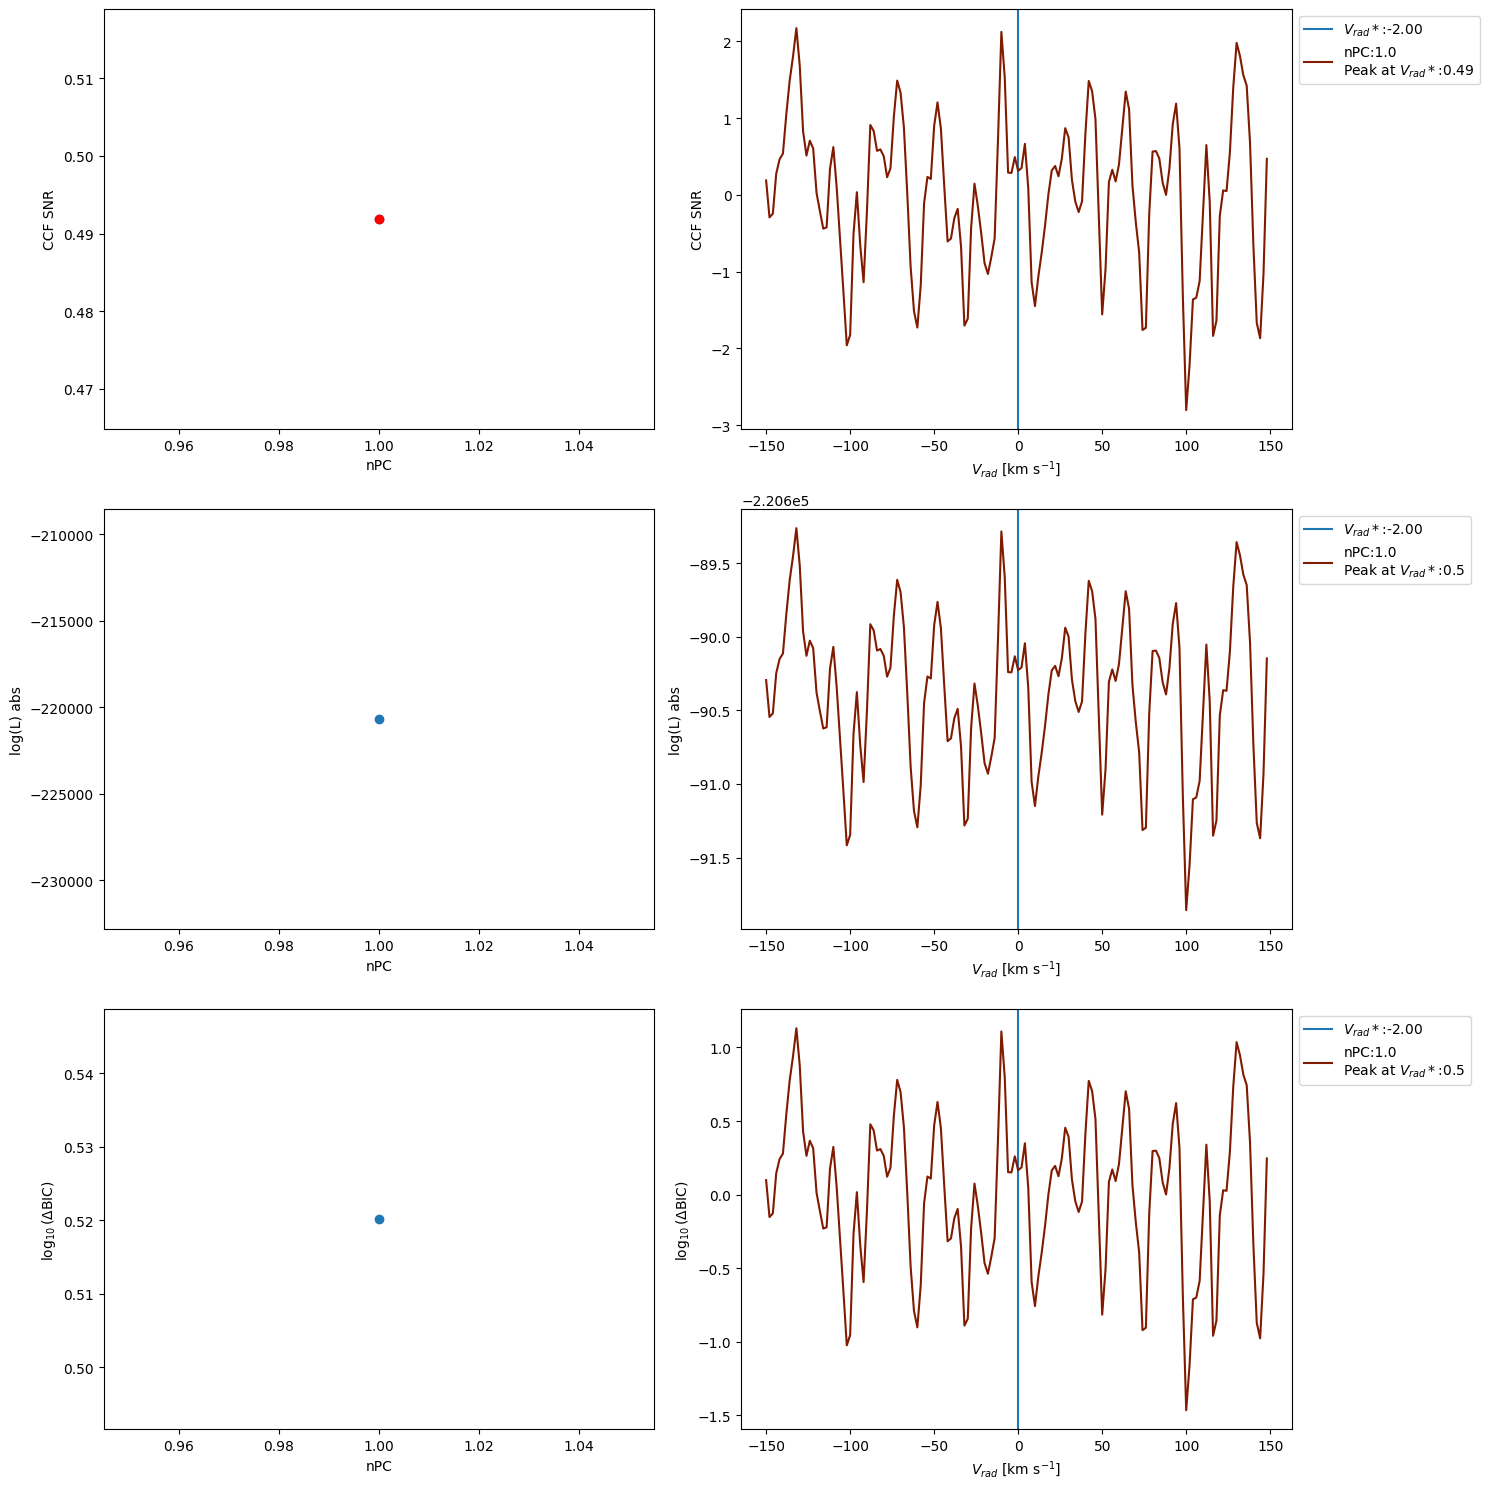

CCF SNR peak at Vrad*: [0.49185594]
log(L) abs peak at Vrad*: [-220690.1326695]
log_10(ΔBIC) peak at Vrad*: [0.52014836]
Saved file to :  /scratch/mathisb/HRS_correlations/NIRPS/TRAPPIST-1b/Combined/Figures/fig_CCF_2Dcombined_corr_nights1-2-3-_pc1-1-1_mask_wings97-97-97_TRAPPIST-1b_H2O_v03_pc1.pdf
In-transit t-val = 1.40 / p-val 1.77e-01 / sig = 0.93
Out-of-transit t-val = 2.10 / p-val 3.97e-02 / sig = 1.75
T-val : Max value = 3.6 // Max position = 2.9
Histogram for Kp = 83.08 and RV = -2.00


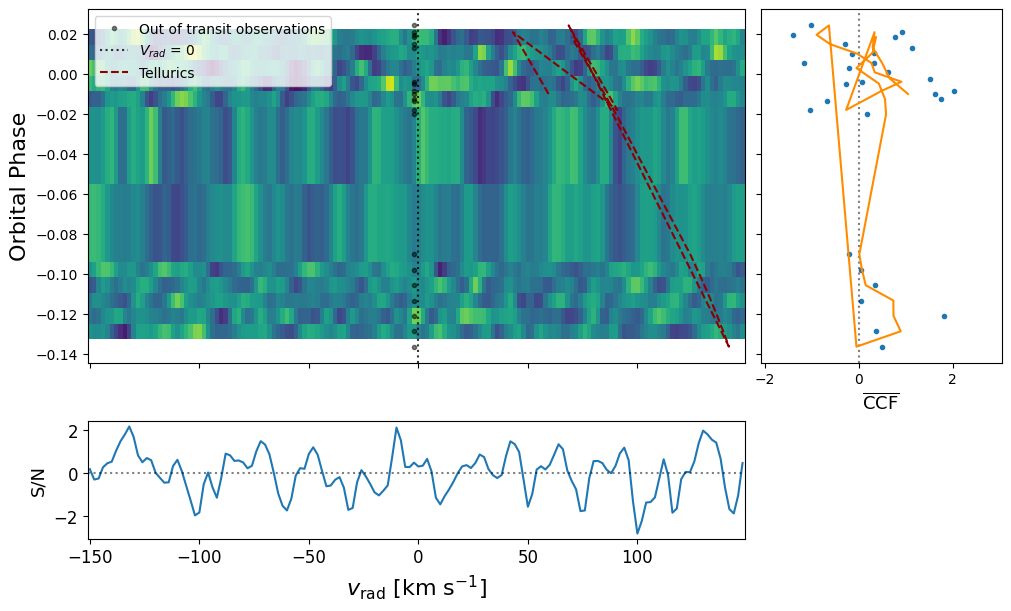

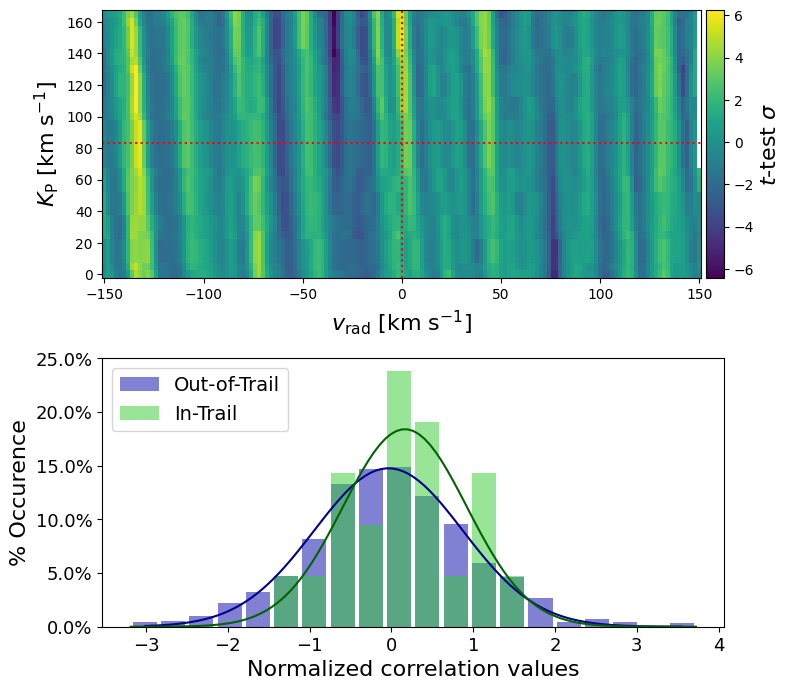

<Figure size 640x480 with 0 Axes>

In [22]:

# CRITERIA TO EXCLUDE AN ORDER
max_masked_ratio = 0.9  # excludes the orders where the ratio of masked data points is too high
min_SNR = 10            # excludes the orders where the instrument SNR is too low
min_model_ppm = 5       # excludes the orders where the model atmosphere is close to 0 ppm in transit depth

# # INDICES OF ORDERS THAT SHOULD NOT BE USED IN THE PLOTS
# orders_to_delete = [[0,1,2,3,4], [10,11,12,13,14], [23,24,25], [37,38,39], [46,47,48]]


# BOX AND SIGMA-CLIPPING METHODS

# Choose Vrad (x-axis) Kp (y-axis) values
rv_grid = corrRV0
kp_grid = np.linspace(-obs.Kp.value, obs.Kp.value, 161)

# Set Vrad and Kp limits for the box in the box method
box_Vrad = (50, 150)
box_Kp = (-60, -35)

# Set sigma limit and max number of iterations for the sigma-clipping method
clip_sigma = 2
clip_iter = 9


#-------------------------------------------------------------------------------------#


# Where to output the combined correlations
output_dir_comb = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/Combined/')

# Figures directory
fig_dir_comb = str(output_dir_comb) + "/Figures/"


# Create filename for combined correlation file
args_filename = []
        
for i in range(len(file_arr)):
    args_filename.append((str(visit_dict[str(i + 1)].params[5]), str(int(visit_dict[str(i + 1)].params[1] * 100))))

args_filename = ['-'.join(values) for values in zip(*args_filename)]
filename = 'combined_corr_nights{}'.format(all_visits_str) + '_pc{}_mask_wings{}_'.format(*args_filename) + f"{model_name}"


# Masks for the array of orders
nb_nights = len(file_arr)

masked_ratio_mask = np.empty((nb_nights,75), dtype=bool)  # mask for ratio of masked data points
SNR_mask = np.empty((nb_nights,75), dtype=bool)  # mask for SNR at the instrument

for i in range(nb_nights):
    obs_i = visit_dict[str(i + 1)]
    masked_ratio_mask[i] = np.array([obs_i.final.mask.sum(axis=0).sum(axis=-1) / obs_i.final.shape[0] / obs_i.final.shape[-1]])[0] < max_masked_ratio
    SNR_mask[i] = np.nanmean(obs_i.SNR,axis=0).T > min_SNR
    
masked_ratio_mask_comb = np.all(masked_ratio_mask, axis=0)
SNR_mask_comb = np.all(SNR_mask, axis=0)


# Model depth mask
model_depth_wv_mask = (model_spec - (R_pl.to(u.R_sun).value / R_star.value) **2) * 1e6 > min_model_ppm  # mask for transit depth of the model atmosphere (minus the planet radius) 
interp_mask = interp1d(wave_mod, model_depth_wv_mask.astype(float), bounds_error=False, fill_value=0.0)  # interpolate mask to the data wv array (convert bool to float for interpolation)

model_depth_mask = []

for wv in obs.wave[0]:  # loop over all orders (same wv grid for all observations)
    mask_interp = interp_mask(wv) > 0.5  # convert back to boolean
    frac_higher_than_limit = np.mean(mask_interp)  # fraction of model points higher than minimum ppm
    model_depth_mask.append(frac_higher_than_limit > 0.80)  # orders are accepted if more than 80% of the order has a model > ppm limit

model_depth_mask = np.array(model_depth_mask)


idx_orders = np.arange(obs.nord)[masked_ratio_mask_comb & SNR_mask_comb & model_depth_mask]  # filter the orders

# # Remove each element of orders_to_delete from array of orders
# for elem in orders_to_delete:
#     idx_orders = np.setdiff1d(idx_orders, elem)


# Create the CCF (combined) object
ccf_map = np.concatenate(combined_ccf)
logl_map = np.concatenate(combined_logl)

ccf_obj_comb, logl_obj_comb = cc.plot_ccflogl(all_visits, 
                                    ccf_map,
                                    logl_map,
                                    corrRV0, np.array([obs.Kp.value]),
                                    [nPC], orders=idx_orders,
                                    path_fig=fig_dir_comb,
                                    fig_name=filename,
                                    cmap='viridis'
                                   )


# Plot the CCF
ccf_obj_comb.ttest_map(all_visits, kind='logl', vrp=np.zeros_like(all_visits.vrp), orders=idx_orders, kp0=0, cmap='viridis',
                  RV_limit=150, kp_step=5, rv_step=2, RV=None, speed_limit=3, icorr=all_visits.iIn, equal_var=False)


# Save combined correlation
pl_obs.save_sequences(filename, visit_dict, [int(all_visits_str.replace("-", ""))], path=output_dir_comb, print_out=False)


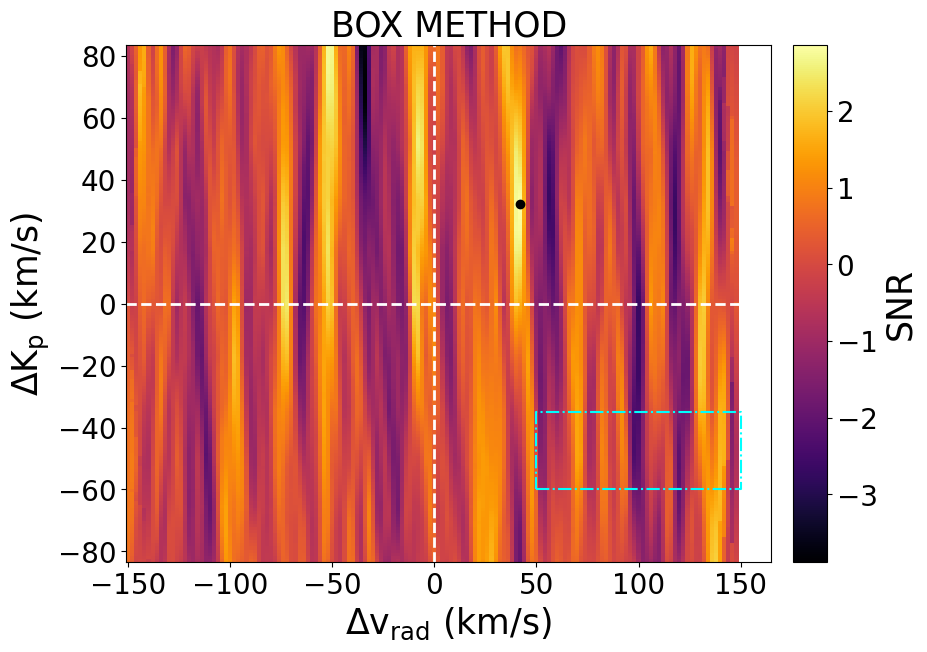

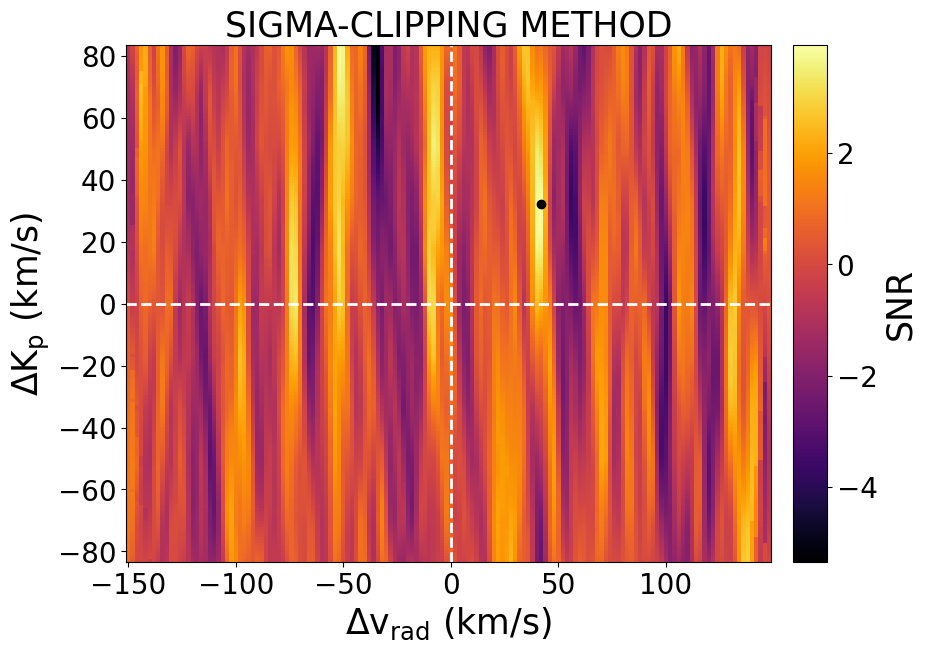

In [23]:
# Plot box and sigma-clipping methods
pf.calculate_KpVsys_map(all_visits, ccf_obj_comb, method='box', rv_grid=rv_grid, kp_grid=kp_grid,
                        box_Vrad=box_Vrad, box_Kp=box_Kp)
pf.calculate_KpVsys_map(all_visits, ccf_obj_comb, method='clip', rv_grid=rv_grid, kp_grid=kp_grid,
                        clip_sigma=clip_sigma, clip_iter=clip_iter)

## Sensitivity vs number of transits (optional)

In [ ]:
# This was done one group of transits at a time (first running the combined corr. with 1 transit, then 2, then 3...).
# If done again, this would need to be adapted in some way and added into the code above, or the code above could be
# copied here and run just once to get the final plot.


# # Create lists of cross-correlation values
# nb_transits_list = []
# std_dev_list = []
# signal_str_list = []


# # GET CCF VALUES FOR EACH Vrad (to do in the code above)
# ccf_vals = ccf_obj.logl.squeeze()
# nb_transits_list.append(len(file_arr))


# # GET STD DEVIATION OF CCF OUTSIDE OF TRAIL
# # Get ccf values outside trail (v_rad = -150 to -100 and 100 to 150)
# ccf_outside_trail = np.concatenate((ccf_vals[:24], ccf_vals[117:]), axis=0)

# # Calculate std deviation
# ccf_std_dev = np.std(ccf_outside_trail)
# print(f"Standard deviation with {len(file_arr)} transits is", ccf_std_dev)

# std_dev_list.append(ccf_std_dev)


# # GET SIGNAL STRENGTH AT Vrad = 0
# # Get ccf values around Vrad = 0
# ccf_at_zero = ccf_vals[68:73]

# # Calculate mean signal
# ccf_mean = np.mean(ccf_at_zero)
# print(f"Mean ccf signal value with {len(file_arr)} transits is", ccf_mean)

# signal_str_list.append(ccf_mean)


# # Check that everything makes sense
# print(np.shape(ccf_vals))
# print(np.shape(ccf_outside_trail))
# print(np.shape(ccf_at_zero))

# plt.figure(figsize=(4.3,4))
# plt.plot(corrRV0, ccf_vals)  # should look like the CCF SNR plot above
# plt.show()

In [ ]:
# # PLOT NOISE AND SIGNAL VS NB OF TRANSITS
# std_dev_arr = np.array(std_dev_list) * 10e3
# signal_str_arr = np.array(signal_str_list) * 10e3

# plt.scatter(nb_transits_list, std_dev_arr, color="mediumblue", s=60, label="Standard deviation outside trail")
# plt.scatter(nb_transits_list, signal_str_arr, color="gold", s=60, label="Signal strength")

# plt.xlabel("Number of nights")
# plt.ylabel("Cross-correlation value [x$10^{3}$]")
# plt.legend()
# plt.show()